In [1]:
# ============================================================
# 1. INSTALL & IMPORT LIBRARIES
# ============================================================

# Install dependencies as needed:
%%capture
!pip install kagglehub[pandas-datasets]

In [2]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Visualization
import plotly.express as px
import plotly.graph_objects as go

# Date Handling
from datetime import datetime

# Encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Feature Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Statistics
from scipy.stats import zscore

# Utility
import ast
import json
import os

# Styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ============================================================
# LOAD DATASET
# ============================================================
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load movies dataset
movies_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "tmdb/tmdb-movie-metadata",
    "tmdb_5000_movies.csv",
)

# Load credits dataset
credits_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "tmdb/tmdb-movie-metadata",
    "tmdb_5000_credits.csv",
)

print("Movies Dataset Shape:", movies_df.shape)
print("Credits Dataset Shape:", credits_df.shape)

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Movies Dataset Shape: (4803, 20)
Credits Dataset Shape: (4803, 4)


In [4]:
print("\nMovies:")
movies_df.sample(5)


Movies:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
3799,4000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",NaN,81390,"[{""id"": 321, ""name"": ""terror""}, {""id"": 388, ""n...",en,A Lonely Place to Die,A group of five mountaineers are hiking and cl...,8.307230,"[{""name"": ""Carnaby International"", ""id"": 4098}...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2011-04-09,25345000,99.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,"Out here, there's nowhere to hide.",A Lonely Place to Die,6.2,157
3153,10000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 27, ""nam...",NaN,244316,"[{""id"": 2522, ""name"": ""grizzly bear""}, {""id"": ...",en,Into the Grizzly Maze,Two estranged brothers reunite at their childh...,10.073144,"[{""name"": ""Purple Pictures"", ""id"": 3217}, {""na...","[{""iso_3166_1"": ""CA"", ""name"": ""Canada""}, {""iso...",2015-02-27,0,94.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Hunt or be hunted.,Into the Grizzly Maze,5.1,74
4543,0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 35, ""name...",NaN,73511,[],en,The Californians,When real estate mogul Gavin Ransom (Noah Wyle...,0.218736,"[{""name"": ""Parker Film Company"", ""id"": 68599}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2005-10-21,0,91.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,All is fair in love and real estate.,The Californians,4.0,1
737,60000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 18, ""nam...",NaN,137094,"[{""id"": 212, ""name"": ""london england""}, {""id"":...",en,Jack Ryan: Shadow Recruit,"Jack Ryan, as a young covert CIA analyst, unco...",42.538258,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...","[{""iso_3166_1"": ""RU"", ""name"": ""Russia""}, {""iso...",2014-01-15,50549107,105.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Trust no one.,Jack Ryan: Shadow Recruit,5.9,1173
4520,0,"[{""id"": 99, ""name"": ""Documentary""}]",NaN,35199,"[{""id"": 271, ""name"": ""competition""}, {""id"": 10...",en,Wordplay,From the masters who create the mind-bending d...,0.906096,[],[],2006-06-26,0,94.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,Wordplay,7.3,10


In [5]:
print("\nCredits:")
credits_df.sample(5)


Credits:


,movie_id,title,cast,crew
3049,9893,Sleepover,"[{""cast_id"": 18, ""character"": ""Julie Corky"", ""...","[{""credit_id"": ""52fe4542c3a36847f80c4103"", ""de..."
2024,783,Gandhi,"[{""cast_id"": 7, ""character"": ""Mahatma Gandhi"",...","[{""credit_id"": ""574dc2c3925141120e0000cb"", ""de..."
3797,227975,Futuro Beach,"[{""cast_id"": 1, ""character"": ""Donato"", ""credit...","[{""credit_id"": ""58c65d74c3a36840f6012c34"", ""de..."
378,8665,K-19: The Widowmaker,"[{""cast_id"": 1, ""character"": ""Alexei Vostrikov...","[{""credit_id"": ""52fe44b2c3a36847f80a500f"", ""de..."
4748,74777,Absentia,"[{""cast_id"": 3, ""character"": ""Callie"", ""credit...","[{""credit_id"": ""52fe48ddc3a368484e10ef89"", ""de..."


In [6]:
# ============================================================
# MERGE DATASETS
# ============================================================

credits_df = credits_df.rename(columns={"movie_id": "id"})

movie_df = pd.merge(
    movies_df,
    credits_df,
    on="title",
    how="left"
)

print("Merged Dataset Shape:")
print(movie_df.shape)

Merged Dataset Shape:
(4809, 23)


In [7]:
# ============================================================
# INITIAL DATA EXPLORATION
# ============================================================

print("First 5 Records")
display(movie_df.head())

First 5 Records


,budget,genres,homepage,id_x,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,id_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [8]:
print("\nRandom Sample")
display(movie_df.sample(5))


Random Sample


,budget,genres,homepage,id_x,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,id_y,cast,crew
4759,60000,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 27, ""n...",NaN,193603,"[{""id"": 3358, ""name"": ""haunted house""}, {""id"":...",en,Hayride,A college student returning home for Halloween...,0.412342,[],...,93.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Southern Fried Horror,Hayride,5.1,6,193603,"[{""cast_id"": 1, ""character"": ""Morgan"", ""credit...","[{""credit_id"": ""54ff2ee69251413da10000ac"", ""de..."
3245,8000000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name...",NaN,10734,"[{""id"": 378, ""name"": ""prison""}, {""id"": 818, ""n...",en,Escape from Alcatraz,Escape from Alcatraz tells the story of the on...,26.356697,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",...,111.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,No one has ever escaped from Alcatraz...and no...,Escape from Alcatraz,7.2,561,10734,"[{""cast_id"": 30, ""character"": ""Frank Morris"", ...","[{""credit_id"": ""57cc487ac3a3683093000df4"", ""de..."
2574,15000000,"[{""id"": 18, ""name"": ""Drama""}]",NaN,4995,"[{""id"": 445, ""name"": ""pornography""}, {""id"": 57...",en,Boogie Nights,"Set in 1977, back when sex was safe, pleasure ...",19.855790,"[{""name"": ""New Line Cinema"", ""id"": 12}, {""name...",...,155.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"The life of a dreamer, the days of a business,...",Boogie Nights,7.5,796,4995,"[{""cast_id"": 8, ""character"": ""Eddie Adams alia...","[{""credit_id"": ""52fe43edc3a36847f8078b3f"", ""de..."
692,150000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...",http://movies.disney.com/chicken-little,9982,"[{""id"": 1357, ""name"": ""fish""}, {""id"": 1415, ""n...",en,Chicken Little,When the sky really is falling and sanity has ...,47.973995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,81.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"When it comes to saving the world, it helps to...",Chicken Little,5.6,944,9982,"[{""cast_id"": 19, ""character"": ""Chicken Little ...","[{""credit_id"": ""52fe4557c3a36847f80c8aff"", ""de..."
4042,2400000,"[{""id"": 18, ""name"": ""Drama""}]",NaN,49471,"[{""id"": 521, ""name"": ""washington d.c.""}, {""id""...",en,Get on the Bus,Get On the Bus follows several Black men on a ...,4.623059,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"On October 16, 1996, the one year anniversary ...",Get on the Bus,7.0,11,49471,"[{""cast_id"": 3, ""character"": ""Jeremiah"", ""cred...","[{""credit_id"": ""52fe4796c3a36847f813dc6f"", ""de..."


In [9]:
print("\nData Types")
display(movie_df.dtypes)


Data Types


,0
budget,int64
genres,object
homepage,object
id_x,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object


In [10]:
print("\nSummary Statistics")
display(movie_df.describe(include="all"))


Summary Statistics


,budget,genres,homepage,id_x,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,id_y,cast,crew
count,4.809000e+03,4809,1713,4809.000000,4809,4809,4809,4806,4809.000000,4809,...,4807.000000,4809,4809,3965,4809,4809.000000,4809.000000,4809.000000,4809,4809
unique,NaN,1175,1691,NaN,4222,37,4801,4800,NaN,3697,...,NaN,544,3,3944,4800,NaN,NaN,NaN,4761,4776
top,NaN,"[{""id"": 18, ""name"": ""Drama""}]",http://www.missionimpossible.com/,NaN,[],en,Batman,A parasitic alien soul is injected into the bo...,NaN,[],...,NaN,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Based on a true story.,The Host,NaN,NaN,NaN,[],[]
freq,NaN,372,4,NaN,412,4510,4,2,NaN,352,...,NaN,3175,4801,3,4,NaN,NaN,NaN,43,28
mean,2.902780e+07,NaN,NaN,57120.571429,NaN,NaN,NaN,NaN,21.491664,NaN,...,106.882255,NaN,NaN,NaN,NaN,6.092514,690.331670,57120.571429,NaN,NaN
std,4.070473e+07,NaN,NaN,88653.369849,NaN,NaN,NaN,NaN,31.803366,NaN,...,22.602535,NaN,NaN,NaN,NaN,1.193989,1234.187111,88653.369849,NaN,NaN
min,0.000000e+00,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,5.000000,NaN,NaN
25%,7.800000e+05,NaN,NaN,9012.000000,NaN,NaN,NaN,NaN,4.667230,NaN,...,94.000000,NaN,NaN,NaN,NaN,5.600000,54.000000,9012.000000,NaN,NaN
50%,1.500000e+07,NaN,NaN,14624.000000,NaN,NaN,NaN,NaN,12.921594,NaN,...,103.000000,NaN,NaN,NaN,NaN,6.200000,235.000000,14624.000000,NaN,NaN
75%,4.000000e+07,NaN,NaN,58595.000000,NaN,NaN,NaN,NaN,28.350529,NaN,...,118.000000,NaN,NaN,NaN,NaN,6.800000,737.000000,58595.000000,NaN,NaN


In [11]:
print("\nDataset Information")
movie_df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id_x                  4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  

In [12]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("Number of Movies:", movie_df.shape[0])
print("Number of Features:", movie_df.shape[1])

if "release_date" in movie_df.columns:

    movie_df["release_date"] = pd.to_datetime(
        movie_df["release_date"],
        errors="coerce"
    )

    print("\nTime Period Covered")
    print(movie_df["release_date"].min())
    print(movie_df["release_date"].max())

Number of Movies: 4809
Number of Features: 23

Time Period Covered
1916-09-04 00:00:00
2017-02-03 00:00:00


In [13]:
# ============================================================
# DATA CLEANING
# ============================================================

movie_df.columns = (
    movie_df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

print("Columns Standardized")

# Remove unnecessary columns

drop_columns = [
    "homepage",
    "tagline",
    "overview"
]

for col in drop_columns:
    if col in movie_df.columns:
        movie_df.drop(col, axis=1, inplace=True)

print("Unnecessary Columns Removed")

Columns Standardized
Unnecessary Columns Removed


In [14]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

missing_values = movie_df.isnull().sum()

missing_df = (
    missing_values
    .sort_values(ascending=False)
    .reset_index()
)

missing_df.columns = ["Column", "Missing_Count"]

display(missing_df.head(20))

,Column,Missing_Count
0,runtime,2
1,release_date,1
2,budget,0
3,genres,0
4,keywords,0
5,id_x,0
6,original_language,0
7,original_title,0
8,production_companies,0
9,popularity,0


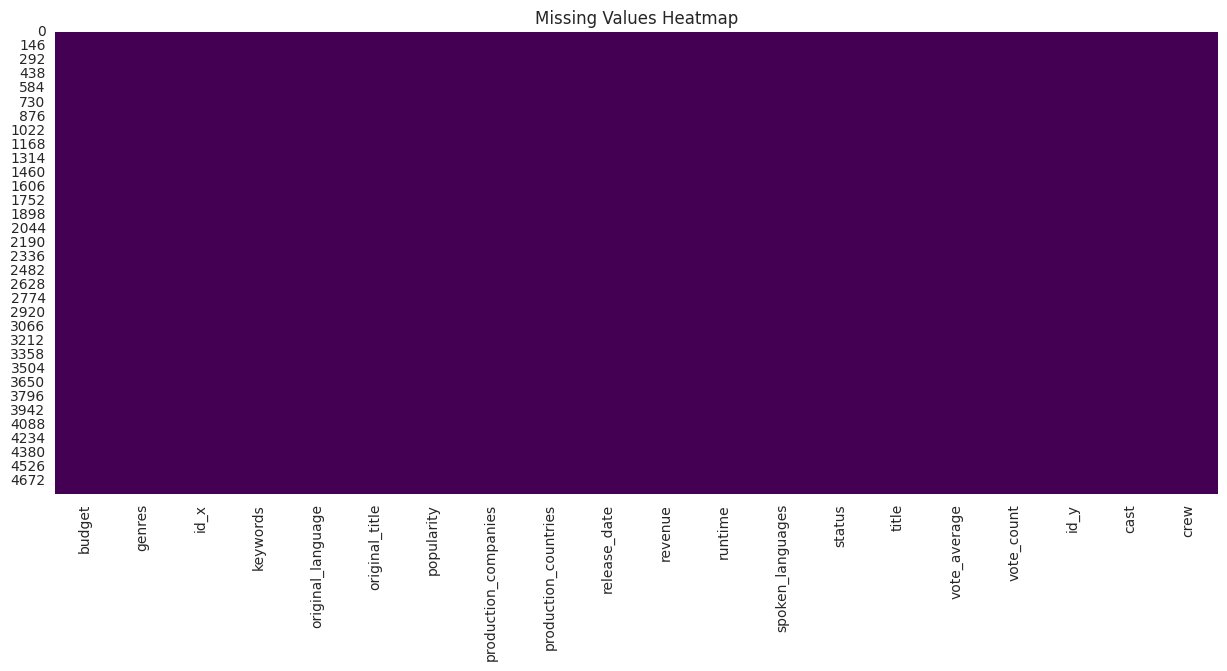

In [15]:
# ============================================================
# MISSING VALUE VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 6))

sns.heatmap(
    movie_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

In [16]:
# ============================================================
# IMPUTATION
# ============================================================

numeric_cols = movie_df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    movie_df[col].fillna(
        movie_df[col].median(),
        inplace=True
    )

categorical_cols = movie_df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:

    movie_df[col].fillna(
        movie_df[col].mode()[0],
        inplace=True
    )

print("Missing Values Handled")

Missing Values Handled


In [17]:
# ============================================================
# VERIFY MISSING VALUES
# ============================================================

print("Remaining Missing Values:")
print(movie_df.isnull().sum().sum())

Remaining Missing Values:
1


In [18]:
# ============================================================
# HANDLE DUPLICATES
# ============================================================

duplicates = movie_df.duplicated().sum()

print("Duplicate Records:", duplicates)

movie_df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:")
print(movie_df.shape)

Duplicate Records: 0
Shape After Removing Duplicates:
(4809, 20)


In [19]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

movie_df["release_year"] = movie_df["release_date"].dt.year
movie_df["release_month"] = movie_df["release_date"].dt.month

movie_df["profit"] = (
    movie_df["revenue"] -
    movie_df["budget"]
)

movie_df["roi"] = np.where(
    movie_df["budget"] > 0,
    movie_df["profit"] / movie_df["budget"],
    0
)

current_year = datetime.now().year

movie_df["movie_age"] = (
    current_year -
    movie_df["release_year"]
)

movie_df["decade"] = (
    movie_df["release_year"] // 10
) * 10

print("Feature Engineering Complete")

Feature Engineering Complete


In [20]:
# ============================================================
# GENRE PARSING FUNCTION
# ============================================================

def extract_genres(text):

    try:

        genres = ast.literal_eval(text)

        return [
            item["name"]
            for item in genres
        ]

    except:

        return []

movie_df["genre_list"] = (
    movie_df["genres"]
    .apply(extract_genres)
)

movie_df["genre_count"] = (
    movie_df["genre_list"]
    .apply(len)
)

movie_df["primary_genre"] = (
    movie_df["genre_list"]
    .apply(
        lambda x: x[0]
        if len(x) > 0
        else "Unknown"
    )
)

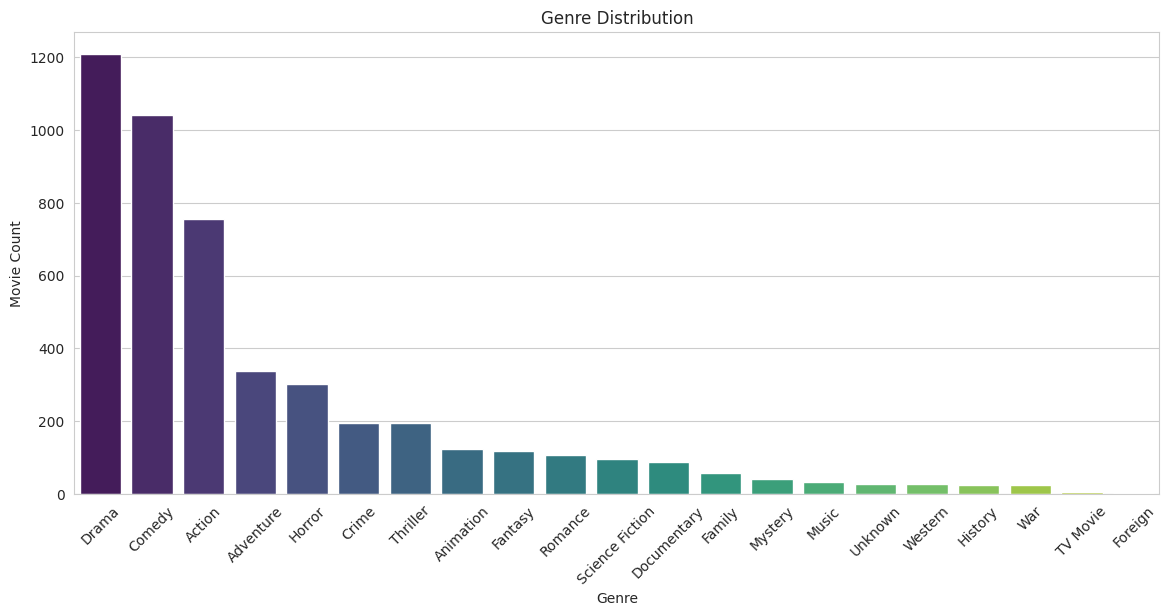

In [21]:
# ============================================================
# GENRE DISTRIBUTION
# ============================================================

genre_counts = (
    movie_df["primary_genre"]
    .value_counts()
)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values,
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Movie Count")
plt.show()

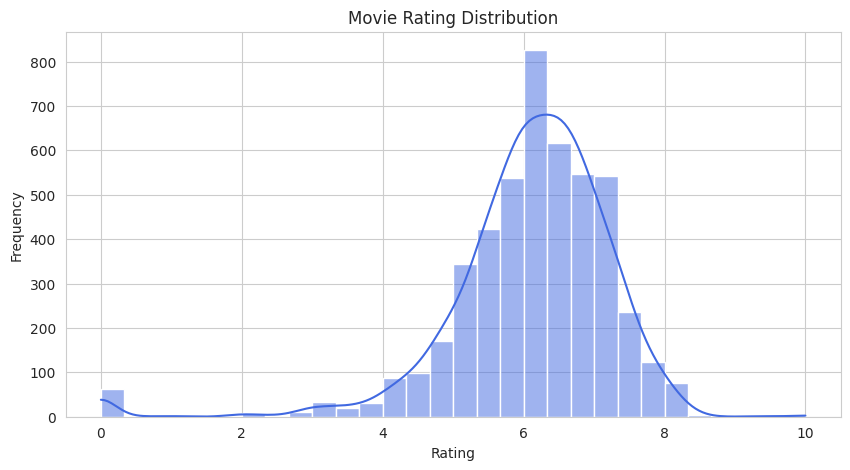

In [22]:
# ============================================================
# RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    movie_df["vote_average"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

In [23]:
# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

movie_df["primary_genre_encoded"] = (
    label_encoder.fit_transform(
        movie_df["primary_genre"]
    )
)

print("Label Encoding Complete")

Label Encoding Complete


In [24]:
# ============================================================
# ONE HOT ENCODING
# ============================================================

genre_dummies = pd.get_dummies(
    movie_df["primary_genre"],
    prefix="genre"
)

movie_df = pd.concat(
    [movie_df, genre_dummies],
    axis=1
)

print("One-Hot Encoding Complete")

One-Hot Encoding Complete


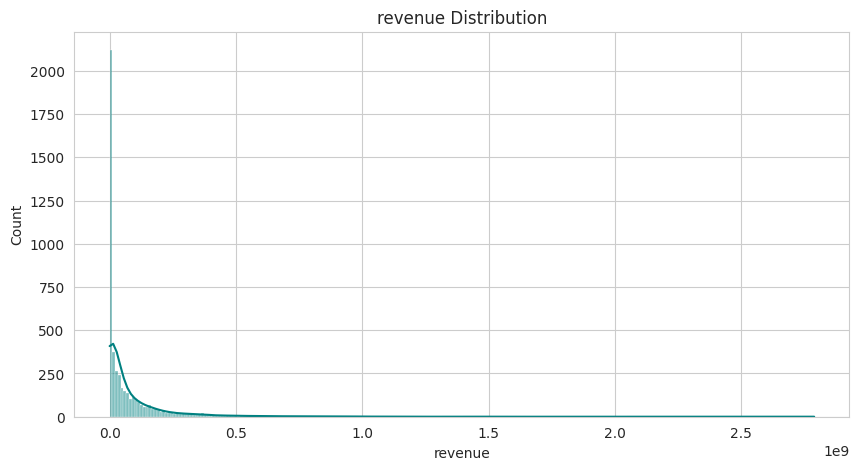

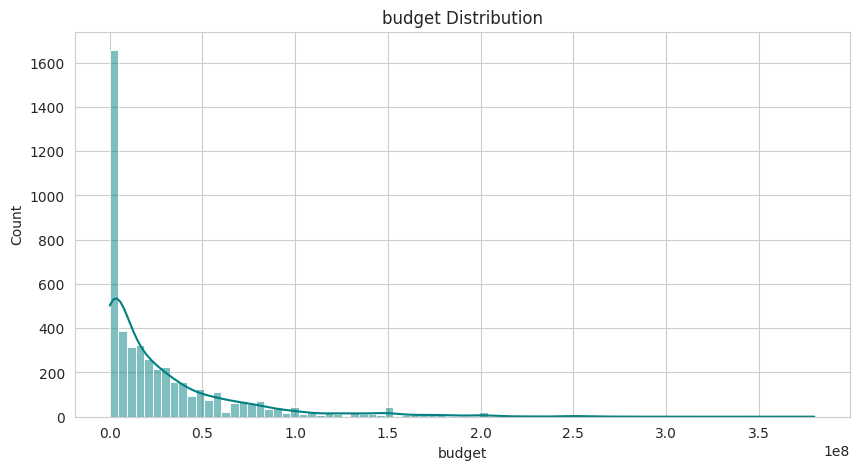

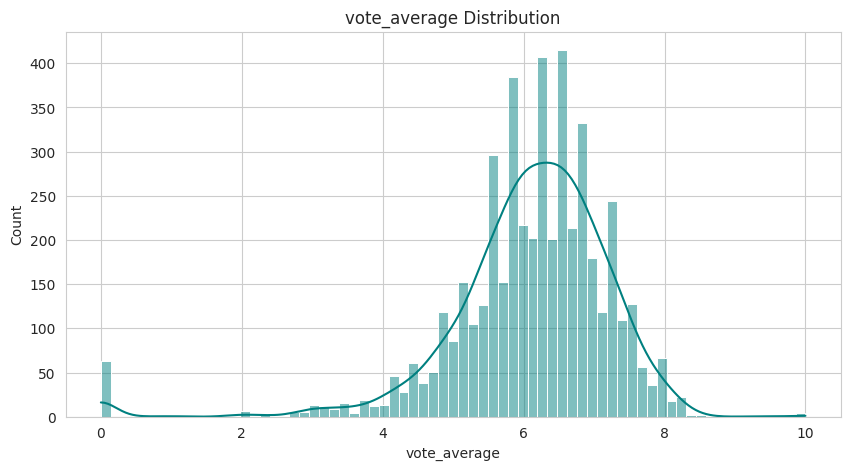

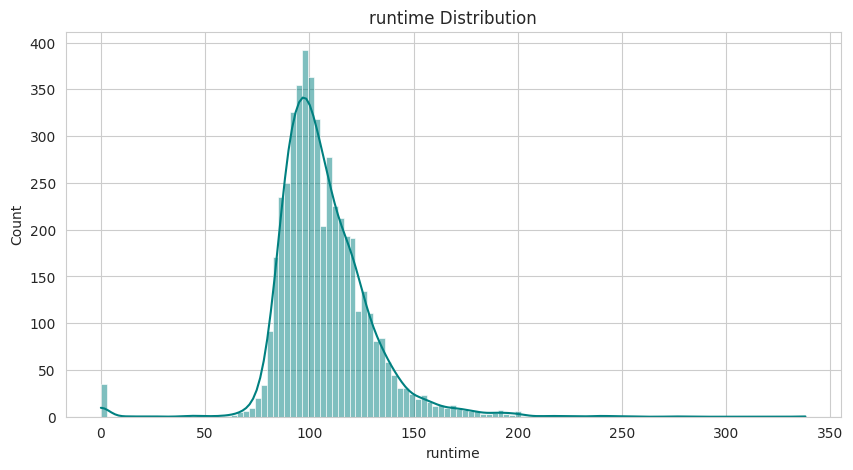

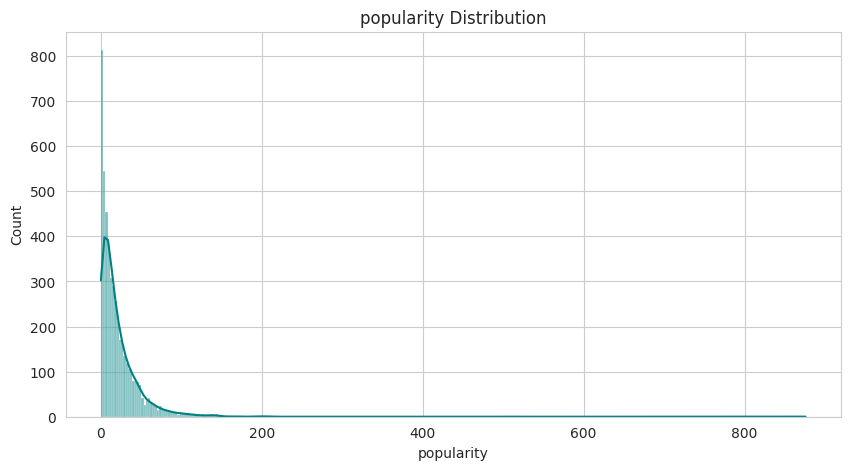

In [25]:
# ============================================================
# UNIVARIATE ANALYSIS
# ============================================================

features = [
    "revenue",
    "budget",
    "vote_average",
    "runtime",
    "popularity"
]

for feature in features:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        movie_df[feature],
        kde=True,
        color="teal"
    )

    plt.title(f"{feature} Distribution")

    plt.show()

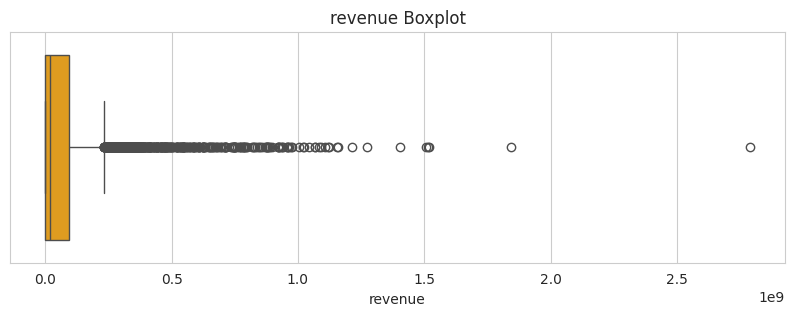

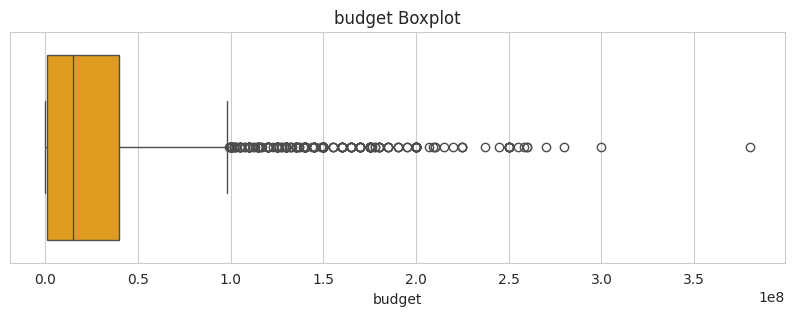

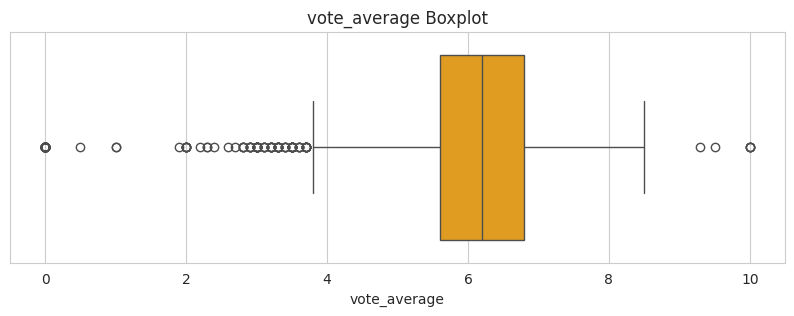

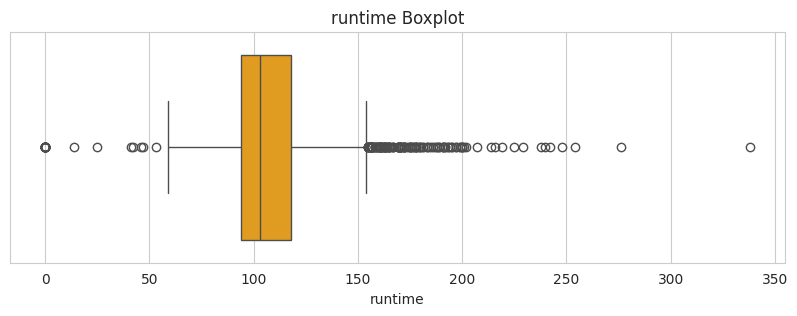

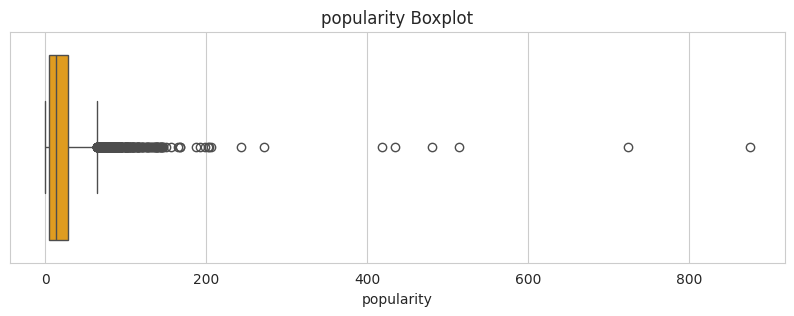

In [26]:
# ============================================================
# BOXPLOTS
# ============================================================

for feature in features:

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=movie_df[feature],
        color="orange"
    )

    plt.title(f"{feature} Boxplot")

    plt.show()

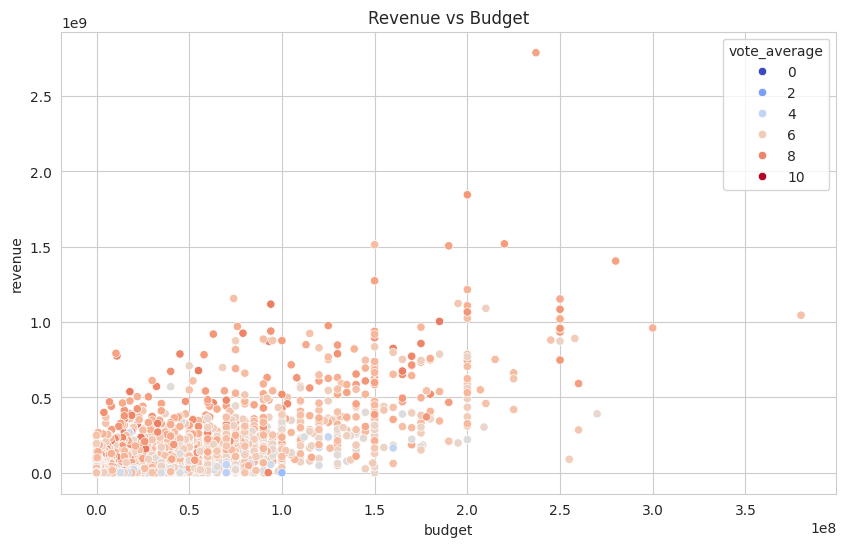

In [27]:
# ============================================================
# REVENUE VS BUDGET
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movie_df,
    x="budget",
    y="revenue",
    hue="vote_average",
    palette="coolwarm"
)

plt.title("Revenue vs Budget")

plt.show()

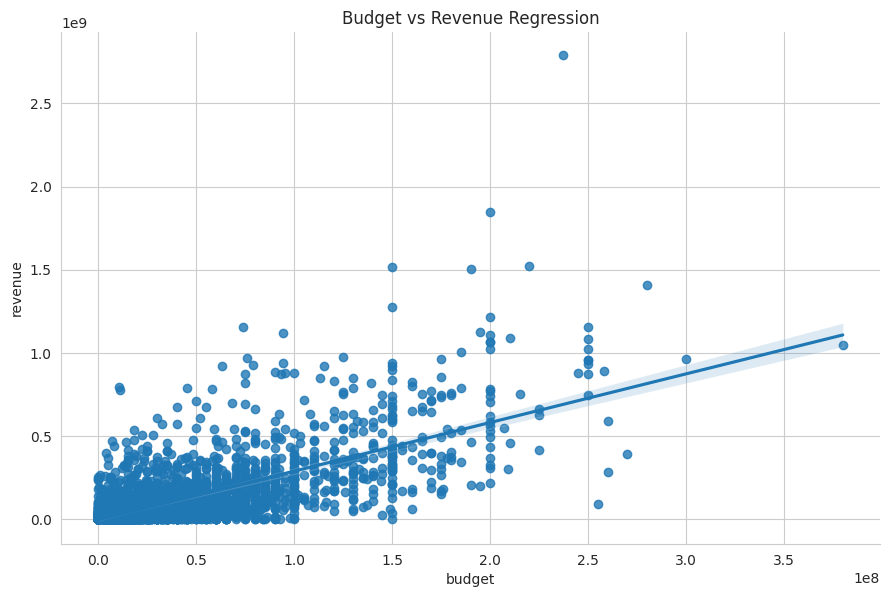

In [28]:
# ============================================================
# REGRESSION PLOT
# ============================================================

sns.lmplot(
    data=movie_df,
    x="budget",
    y="revenue",
    height=6,
    aspect=1.5
)

plt.title("Budget vs Revenue Regression")

plt.show()

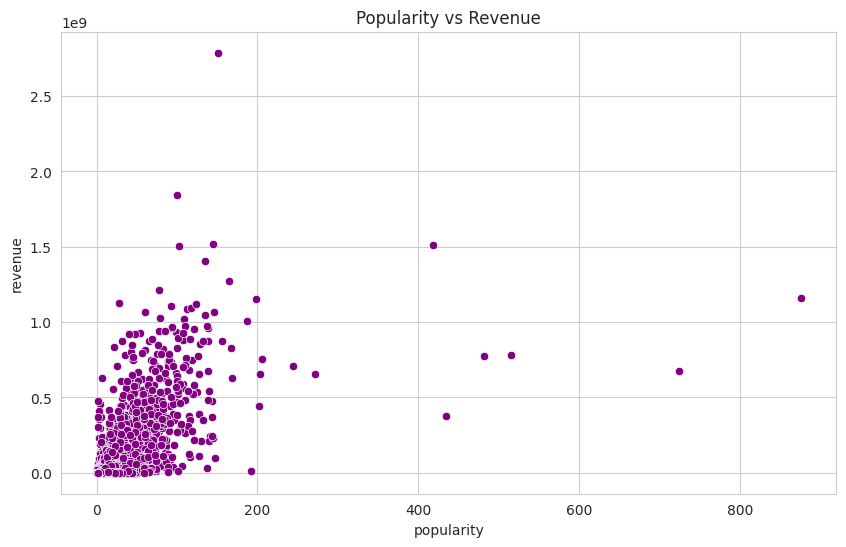

In [29]:
# ============================================================
# POPULARITY VS REVENUE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movie_df,
    x="popularity",
    y="revenue",
    color="purple"
)

plt.title("Popularity vs Revenue")

plt.show()

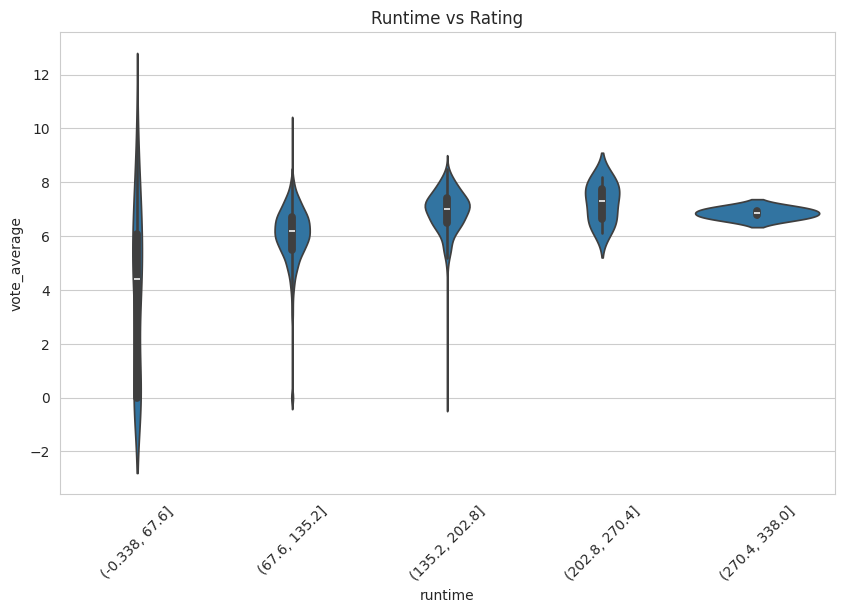

In [30]:
# ============================================================
# RUNTIME VS RATING
# ============================================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    x=pd.cut(movie_df["runtime"], bins=5),
    y=movie_df["vote_average"]
)

plt.title("Runtime vs Rating")

plt.xticks(rotation=45)

plt.show()

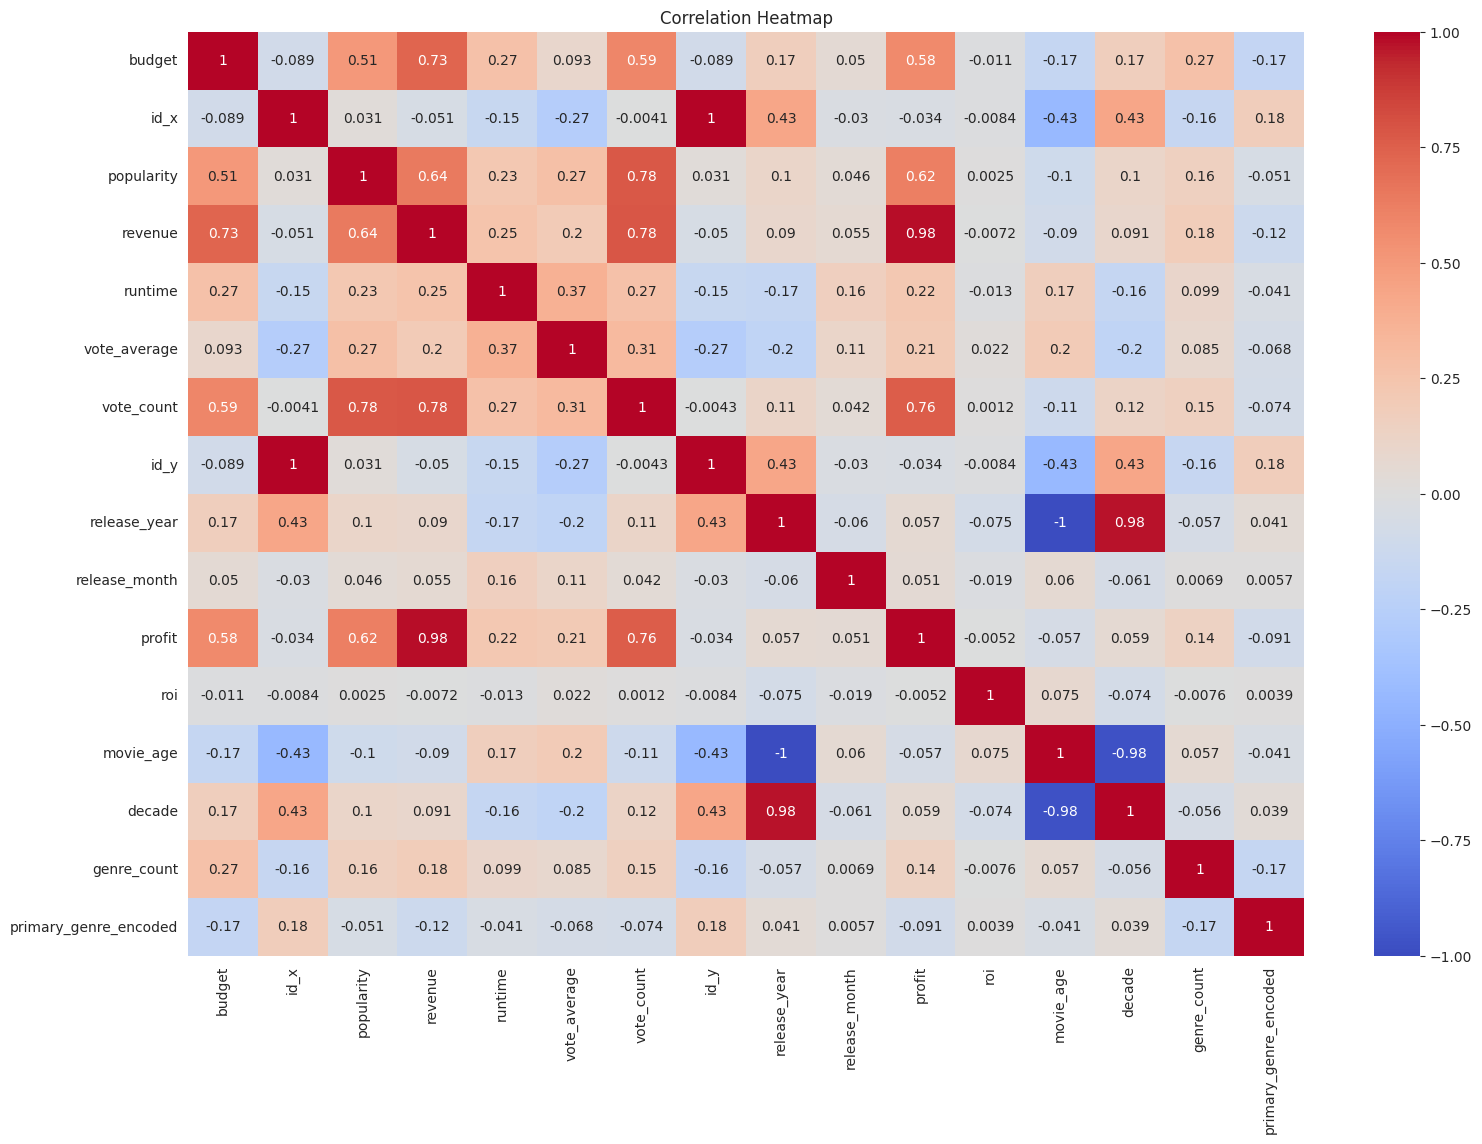

In [31]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

numeric_data = movie_df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_data.corr()

plt.figure(figsize=(18, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

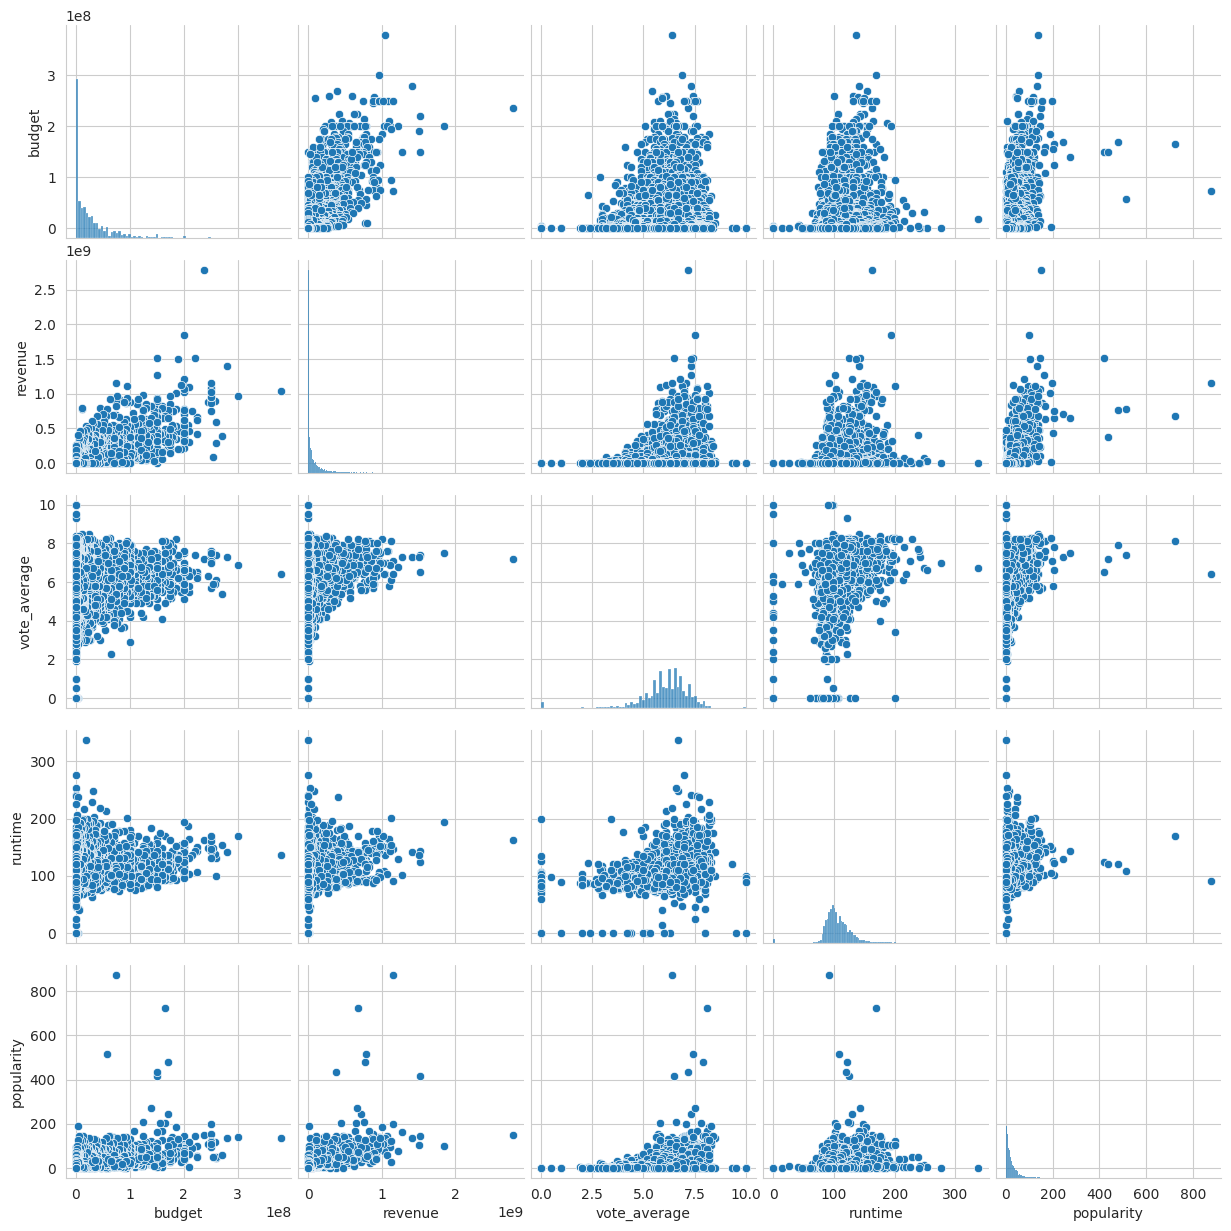

In [32]:
# ============================================================
# PAIRPLOT
# ============================================================

selected_features = [
    "budget",
    "revenue",
    "vote_average",
    "runtime",
    "popularity"
]

sns.pairplot(
    movie_df[selected_features]
)

plt.show()

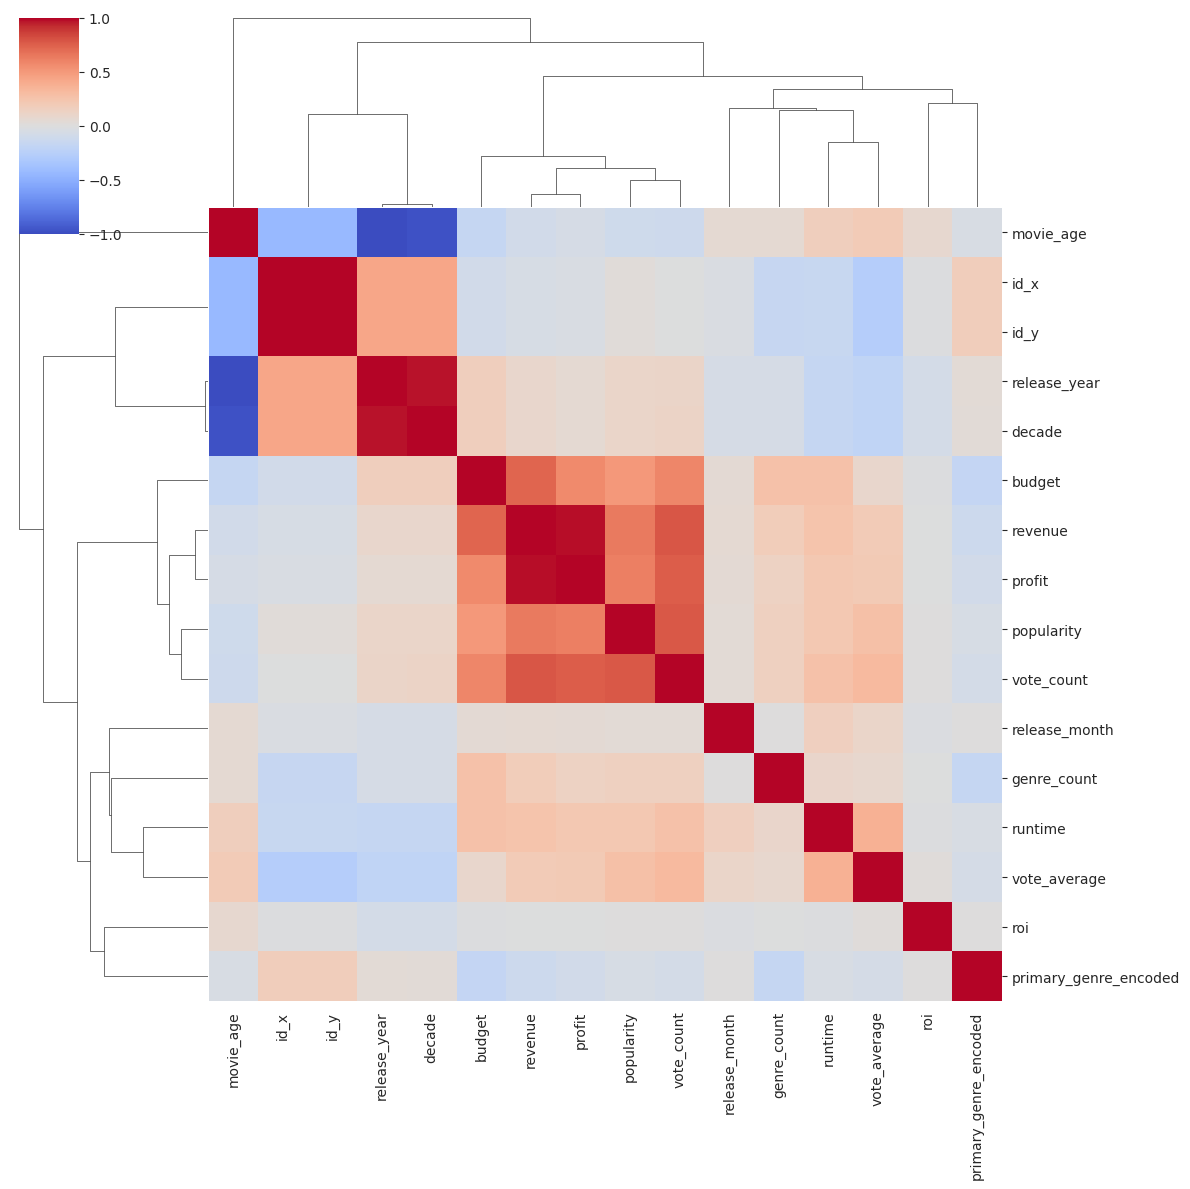

In [33]:
# ============================================================
# CLUSTERED HEATMAP
# ============================================================

sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    figsize=(12, 12)
)

plt.show()

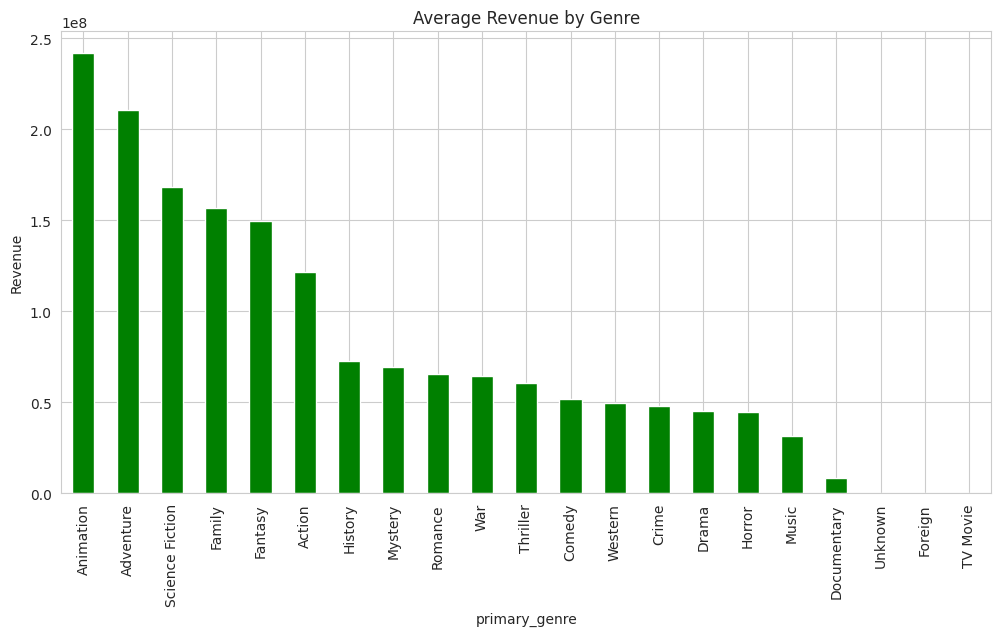

In [34]:
# ============================================================
# GENRE-WISE REVENUE ANALYSIS
# ============================================================

genre_revenue = (
    movie_df
    .groupby("primary_genre")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

genre_revenue.plot(
    kind="bar",
    color="green"
)

plt.title("Average Revenue by Genre")

plt.ylabel("Revenue")

plt.show()

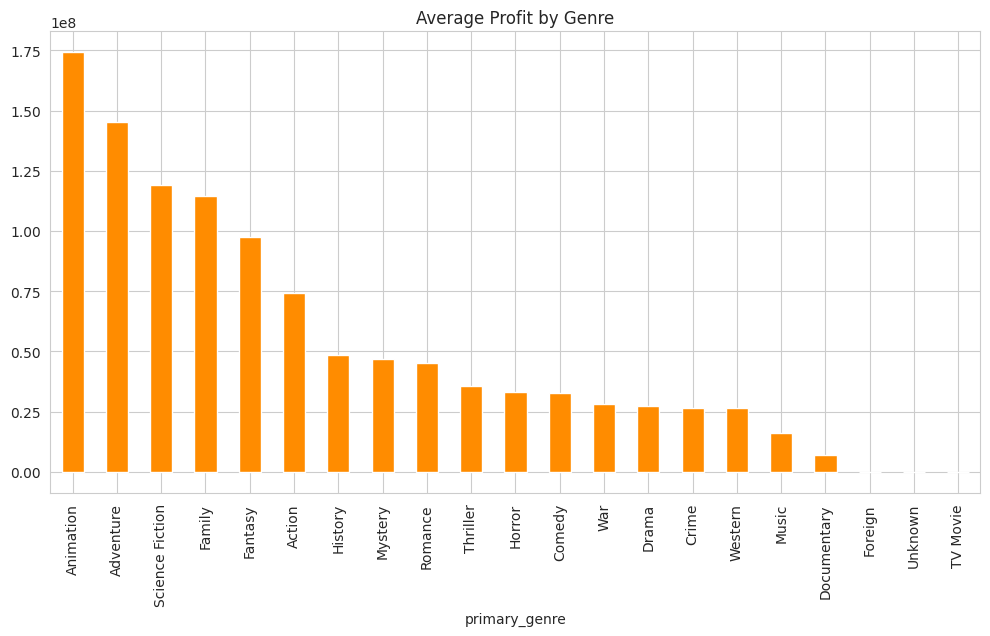

In [35]:
# ============================================================
# GENRE-WISE PROFITABILITY
# ============================================================

genre_profit = (
    movie_df
    .groupby("primary_genre")["profit"]
    .mean()
    .sort_values(ascending=False)
)

genre_profit.plot(
    kind="bar",
    figsize=(12, 6),
    color="darkorange"
)

plt.title("Average Profit by Genre")

plt.show()

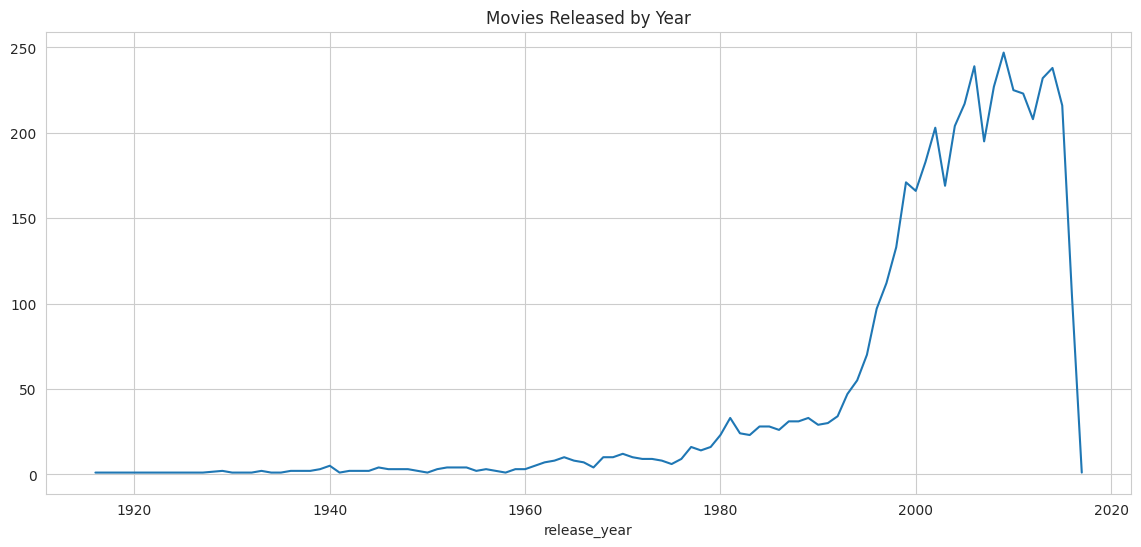

In [36]:
# ============================================================
# MOVIES RELEASED BY YEAR
# ============================================================

movies_per_year = (
    movie_df["release_year"]
    .value_counts()
    .sort_index()
)

movies_per_year.plot(
    figsize=(14, 6)
)

plt.title("Movies Released by Year")

plt.show()

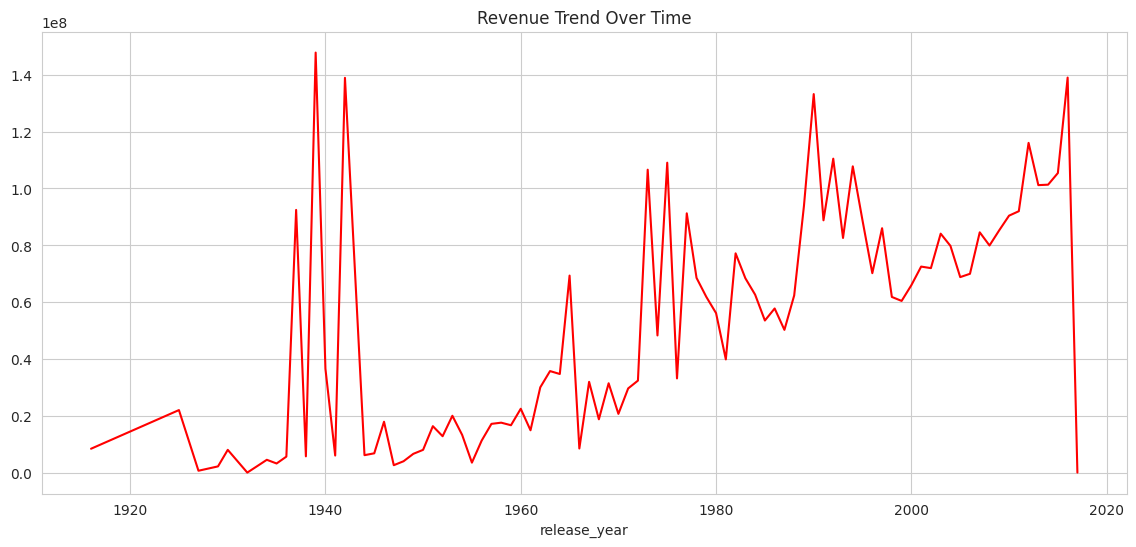

In [37]:
# ============================================================
# REVENUE TREND OVER TIME
# ============================================================

revenue_trend = (
    movie_df
    .groupby("release_year")["revenue"]
    .mean()
)

revenue_trend.plot(
    figsize=(14, 6),
    color="red"
)

plt.title("Revenue Trend Over Time")

plt.show()

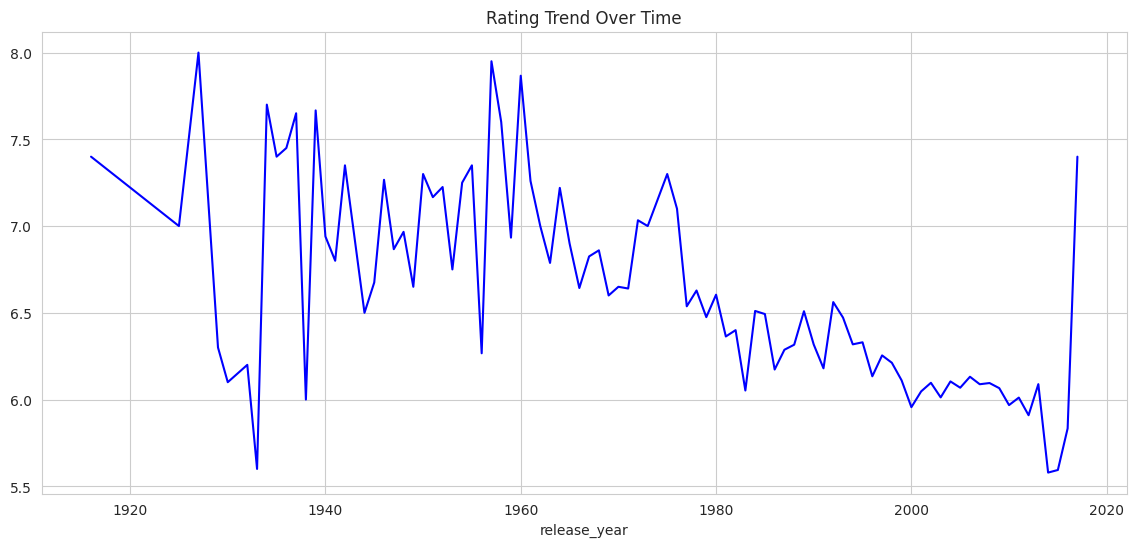

In [38]:
# ============================================================
# RATING TREND OVER TIME
# ============================================================

rating_trend = (
    movie_df
    .groupby("release_year")["vote_average"]
    .mean()
)

rating_trend.plot(
    figsize=(14, 6),
    color="blue"
)

plt.title("Rating Trend Over Time")

plt.show()

In [39]:
# ============================================================
# TOP EARNING MOVIES
# ============================================================

top_revenue = (
    movie_df[
        ["title", "revenue"]
    ]
    .sort_values(
        by="revenue",
        ascending=False
    )
    .head(10)
)

display(top_revenue)

,title,revenue
0,Avatar,2787965087
25,Titanic,1845034188
16,The Avengers,1519557910
28,Jurassic World,1513528810
44,Furious 7,1506249360
7,Avengers: Age of Ultron,1405403694
124,Frozen,1274219009
31,Iron Man 3,1215439994
546,Minions,1156730962
26,Captain America: Civil War,1153304495


In [40]:
# ============================================================
# MOST PROFITABLE MOVIES
# ============================================================

top_profit = (
    movie_df[
        ["title", "profit"]
    ]
    .sort_values(
        by="profit",
        ascending=False
    )
    .head(10)
)

display(top_profit)

,title,profit
0,Avatar,2550965087
25,Titanic,1645034188
28,Jurassic World,1363528810
44,Furious 7,1316249360
16,The Avengers,1299557910
7,Avengers: Age of Ultron,1125403694
124,Frozen,1124219009
546,Minions,1082730962
329,The Lord of the Rings: The Return of the King,1024888979
31,Iron Man 3,1015439994


In [41]:
# ============================================================
# HIGHEST RATED MOVIES
# ============================================================

top_rated = (
    movie_df[
        ["title", "vote_average"]
    ]
    .sort_values(
        by="vote_average",
        ascending=False
    )
    .head(10)
)

display(top_rated)

,title,vote_average
4668,Little Big Top,10.0
4252,Me You and Five Bucks,10.0
4050,"Dancer, Texas Pop. 81",10.0
3522,Stiff Upper Lips,10.0
3997,Sardaarji,9.5
2388,One Man's Hero,9.3
2973,There Goes My Baby,8.5
1883,The Shawshank Redemption,8.5
2798,The Prisoner of Zenda,8.4
3340,The Godfather,8.4


In [42]:
# ============================================================
# MOST POPULAR MOVIES
# ============================================================

top_popular = (
    movie_df[
        ["title", "popularity"]
    ]
    .sort_values(
        by="popularity",
        ascending=False
    )
    .head(10)
)

display(top_popular)

,title,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
28,Jurassic World,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889
82,Dawn of the Planet of the Apes,243.791743
200,The Hunger Games: Mockingjay - Part 1,206.227151
88,Big Hero 6,203.734590


In [43]:
# ============================================================
# PLOTLY TREEMAP
# ============================================================

genre_summary = (
    movie_df
    .groupby("primary_genre")
    .agg(
        Revenue=("revenue", "sum")
    )
    .reset_index()
)

fig = px.treemap(
    genre_summary,
    path=["primary_genre"],
    values="Revenue",
    title="Revenue Distribution by Genre"
)

fig.show()

In [44]:
# ============================================================
# BUBBLE CHART
# ============================================================

fig = px.scatter(
    movie_df,
    x="budget",
    y="revenue",
    size="popularity",
    color="vote_average",
    hover_name="title",
    title="Budget vs Revenue Bubble Chart"
)

fig.show()

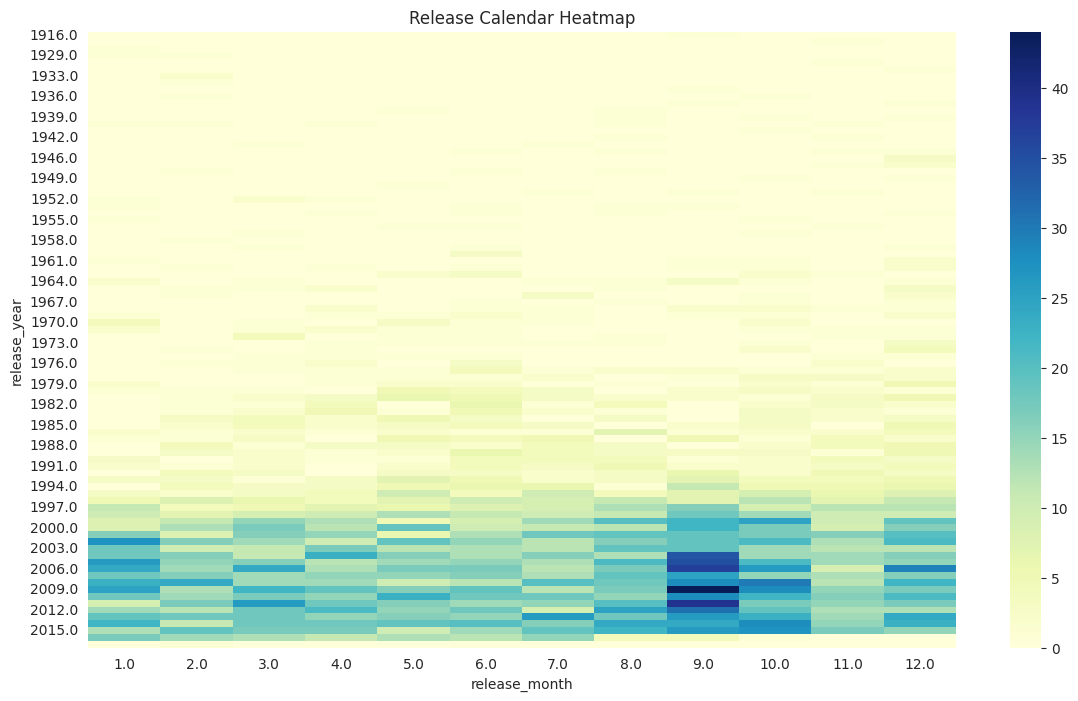

In [45]:
# ============================================================
# RELEASE CALENDAR HEATMAP
# ============================================================

calendar_data = (
    movie_df
    .groupby(
        [
            "release_year",
            "release_month"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    calendar_data,
    cmap="YlGnBu"
)

plt.title("Release Calendar Heatmap")

plt.show()

In [46]:
# ============================================================
# FEATURE SELECTION
# ============================================================

target_variable = "revenue"

numeric_features = (
    movie_df
    .select_dtypes(include=np.number)
)

correlations = (
    numeric_features
    .corr()[target_variable]
    .abs()
    .sort_values(
        ascending=False
    )
)

display(correlations.head(20))

,revenue
revenue,1.000000
profit,0.978885
vote_count,0.781468
budget,0.730584
popularity,0.644724
runtime,0.251362
vote_average,0.197336
genre_count,0.181638
primary_genre_encoded,0.119686
decade,0.091314


In [47]:
# ============================================================
# REMOVE MULTICOLLINEARITY
# ============================================================

corr_matrix = numeric_features.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

drop_features = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly Correlated Features:")
print(drop_features)

Highly Correlated Features:
['id_y', 'profit', 'movie_age', 'decade']


In [48]:
# ============================================================
# MODEL DATA PREPARATION
# ============================================================

selected_features = [
    "budget",
    "popularity",
    "runtime",
    "vote_count",
    "vote_average",
    "release_year",
    "genre_count"
]

movie_df = movie_df.dropna(axis=0)

X = movie_df[selected_features]

y = movie_df["revenue"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (4808, 7)
Target Shape: (4808,)


In [49]:
# ============================================================
# FEATURE SCALING
# ============================================================

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_standard = standard_scaler.fit_transform(X)

X_minmax = minmax_scaler.fit_transform(X)

print("Scaling Complete")

Scaling Complete


In [50]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_standard,
    y,
    test_size=0.20,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (3846, 7)
Test Shape: (962, 7)


In [51]:
# ============================================================
# MODEL TRAINING
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    results[name] = [
        mae,
        mse,
        rmse,
        r2
    ]

    print(f"\n{name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)


Linear Regression
MAE : 46243002.406956784
MSE : 6305946643207741.0
RMSE: 79409990.82739992
R2  : 0.760257355318914

Random Forest
MAE : 40406872.76323631
MSE : 7194709104837295.0
RMSE: 84821631.11398704
R2  : 0.7264679379482726


In [52]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results,
    index=[
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ]
).T

display(results_df)

,MAE,MSE,RMSE,R2
Linear Regression,4.624300e+07,6.305947e+15,7.940999e+07,0.760257
Random Forest,4.040687e+07,7.194709e+15,8.482163e+07,0.726468


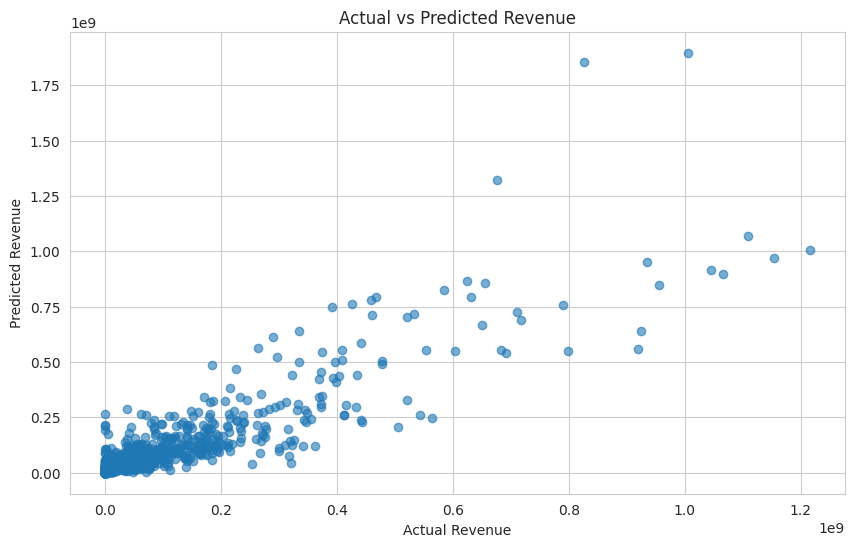

In [53]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

best_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

predictions = best_model.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue")

plt.show()

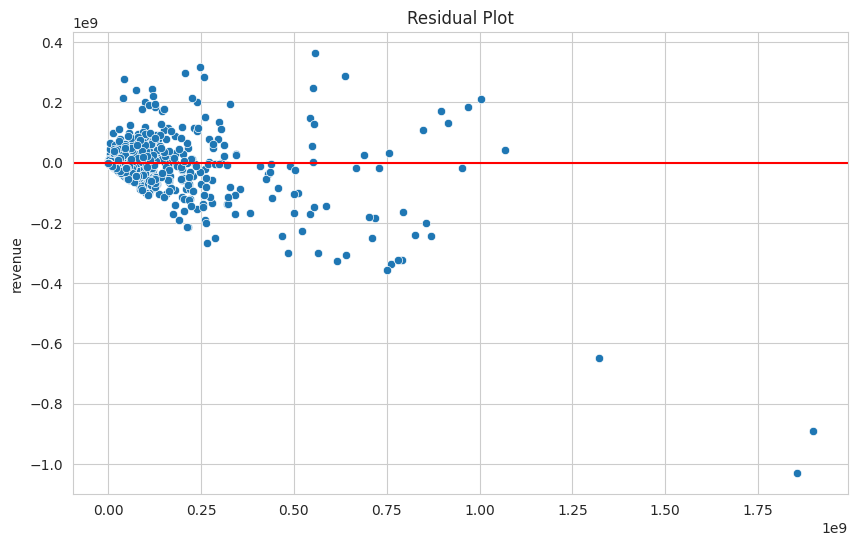

In [54]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = y_test - predictions

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    0,
    color="red"
)

plt.title("Residual Plot")

plt.show()

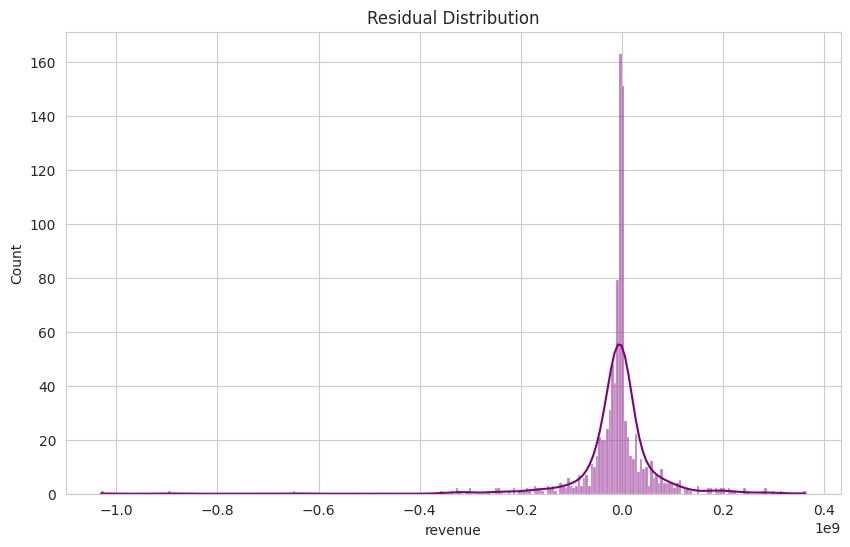

In [55]:
# ============================================================
# ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True,
    color="purple"
)

plt.title("Residual Distribution")

plt.show()

,Feature,Importance
3,vote_count,0.628649
0,budget,0.195231
1,popularity,0.050437
2,runtime,0.043333
5,release_year,0.039717
4,vote_average,0.030215
6,genre_count,0.012418


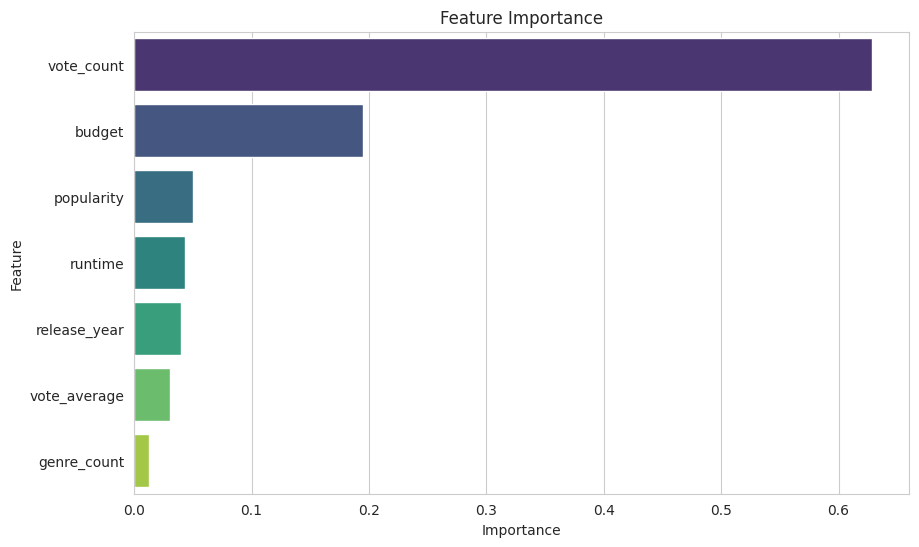

In [56]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(importance_df)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")

plt.show()

In [57]:
# ============================================================
# BUSINESS INSIGHTS
# ============================================================

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

highest_revenue_genre = (
    genre_revenue.idxmax()
)

print(
    f"Highest Revenue Genre: "
    f"{highest_revenue_genre}"
)

budget_revenue_corr = (
    movie_df["budget"]
    .corr(movie_df["revenue"])
)

print(
    f"Budget-Revenue Correlation: "
    f"{budget_revenue_corr:.2f}"
)

best_month = (
    movie_df
    .groupby("release_month")
    ["revenue"]
    .mean()
    .idxmax()
)

print(
    f"Best Release Month: "
    f"{best_month}"
)

print("\nTop Revenue Drivers:")
print(
    importance_df
    .head(5)
)

BUSINESS INSIGHTS
Highest Revenue Genre: Animation
Budget-Revenue Correlation: 0.73
Best Release Month: 6.0

Top Revenue Drivers:
        Feature  Importance
3    vote_count    0.628649
0        budget    0.195231
1    popularity    0.050437
2       runtime    0.043333
5  release_year    0.039717


In [58]:
# ============================================================
# SAVE CLEANED DATASET
# ============================================================

movie_df.to_csv(
    "processed_movie_dataset.csv",
    index=False
)

print(
    "Processed Dataset Saved"
)

Processed Dataset Saved


In [59]:
# ============================================================
# PROJECT CONCLUSION
# ============================================================

print("=" * 70)
print("PROJECT CONCLUSION")
print("=" * 70)

print("""
KEY FINDINGS

1. Revenue is strongly influenced by movie budget.

2. Popularity contributes significantly to box office success.

3. Certain genres consistently outperform others.

4. Release timing impacts financial performance.

5. Machine learning models successfully predict revenue.

6. Random Forest generally performs better than Linear Regression.

BUSINESS RECOMMENDATIONS

• Invest strategically in high-performing genres.
• Optimize release schedules.
• Improve marketing to increase popularity.
• Use predictive analytics before production decisions.

FUTURE IMPROVEMENTS

• Add XGBoost and LightGBM models.
• Include cast and director analysis.
• Perform sentiment analysis on reviews.
• Build recommendation systems.
• Deploy model using Streamlit or Flask.

PROJECT COMPLETED SUCCESSFULLY
""")

PROJECT CONCLUSION

KEY FINDINGS

1. Revenue is strongly influenced by movie budget.

2. Popularity contributes significantly to box office success.

3. Certain genres consistently outperform others.

4. Release timing impacts financial performance.

5. Machine learning models successfully predict revenue.

6. Random Forest generally performs better than Linear Regression.

BUSINESS RECOMMENDATIONS

• Invest strategically in high-performing genres.
• Optimize release schedules.
• Improve marketing to increase popularity.
• Use predictive analytics before production decisions.

FUTURE IMPROVEMENTS

• Add XGBoost and LightGBM models.
• Include cast and director analysis.
• Perform sentiment analysis on reviews.
• Build recommendation systems.
• Deploy model using Streamlit or Flask.

PROJECT COMPLETED SUCCESSFULLY

